## Helen's code to run linear and polynomial regression on the algae bloom data

### Load packages

In [154]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import cross_val_score, KFold

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, make_scorer

%matplotlib inline

### Set file info for this run

In [130]:
# Project parameters

data_directory = r"..\data\merged_csvs"

algae_file = "algae_merged"
algae_path = os.path.join(data_directory, algae_file + ".csv")
print(algae_path)

..\data\merged_csvs\algae_merged.csv


### Load algae bloom data

In [131]:
# Load algae bloom data file

algae_raw_df = pd.read_csv(algae_path)

In [132]:
algae_raw_df.iloc[:5, :]
# vct_raw_df.iloc[:10, 10:25]
# vct_raw_df.iloc[:10, 10:25]

,vct_region,vct_report_date,vct_latitude,vct_longitude,vct_water_temp_trailing,vct_water_surface_trailing,vct_anabaena_trailing,vct_aphanizomenon_trailing,vct_microcystin_trailing,vct_oscillatoria_trailing,...,noaa_WDF5,noaa_TAVG,dec_total nitrogen,dec_total phosphorus,dec_dissolved phosphorus,dec_chlorophyll-a,dec_secchi depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity
0,Main Lake Central,2014-09-30,44.484736,-73.288936,66.608333,Calm,1.0,1.0,0.0,1.0,...,211.428571,15.228571,0.340,12.5,5.00,3.830,5.40,NaN,0,1a
1,Main Lake Central,2014-10-02,44.484736,-73.288936,66.169167,Calm,1.0,1.0,0.0,1.0,...,233.571429,15.328571,0.340,12.5,5.00,3.830,5.40,NaN,1,3
2,Main Lake Central,2015-06-14,44.484736,-73.288936,65.625000,Calm,1.0,0.0,0.0,0.0,...,254.285714,16.521429,0.400,69.6,13.00,2.300,5.00,12.0,0,1b
3,Main Lake Central,2015-06-15,44.484736,-73.288936,65.597222,Calm,1.0,0.0,0.0,0.0,...,250.000000,16.992857,0.400,69.6,13.00,2.300,5.00,12.0,0,1a
4,Main Lake Central,2015-06-16,44.484736,-73.288936,65.347222,Calm,1.0,0.0,0.0,0.0,...,252.142857,17.557143,0.405,39.7,9.65,1.815,4.05,14.2,0,1a


In [133]:
print(len(algae_raw_df.columns))
algae_raw_df.columns

35


Index(['vct_region', 'vct_report_date', 'vct_latitude', 'vct_longitude',
       'vct_water_temp_trailing', 'vct_water_surface_trailing',
       'vct_anabaena_trailing', 'vct_aphanizomenon_trailing',
       'vct_microcystin_trailing', 'vct_oscillatoria_trailing',
       'usgs_water_temp_max_trailing', 'usgs_water_temp_min_trailing',
       'usgs_water_temp_mean_trailing', 'usgs_conductivity_max_trailing',
       'usgs_conductivity_min_trailing', 'usgs_conductivity_mean_trailing',
       'noaa_PRCP', 'noaa_TMAX', 'noaa_TMIN', 'noaa_AWND', 'noaa_WSF2',
       'noaa_SNWD', 'noaa_WDF2', 'noaa_SNOW', 'noaa_WSF5', 'noaa_WDF5',
       'noaa_TAVG', 'dec_total nitrogen', 'dec_total phosphorus',
       'dec_dissolved phosphorus', 'dec_chlorophyll-a', 'dec_secchi depth',
       'dec_temperature', 'vct_target_bloom', 'vct_target_bloom_intensity'],
      dtype='object')

### Clean up and format data columns

In [134]:
# Convert columns to floats, integers, and dates as appropriate

algae_numcols_df = algae_raw_df.copy()

float_cols = ["vct_water_temp_trailing", "usgs_water_temp_max_trailing", "usgs_water_temp_min_trailing", "usgs_water_temp_mean_trailing", 
              "usgs_conductivity_max_trailing", "usgs_conductivity_min_trailing", "usgs_conductivity_mean_trailing",
              "noaa_PRCP", "noaa_TMIN", "noaa_TMAX", "noaa_AWND", "noaa_WDF2", "noaa_WSF2", "noaa_SNWD", "noaa_SNOW",
              "noaa_WSF5", "noaa_WDF5", "noaa_TAVG", "dec_total nitrogen", "dec_total phosphorus", "dec_dissolved phosphorus",
              "dec_chlorophyll-a", "dec_secchi depth", "dec_temperature"]
int_cols = ["vct_anabaena_trailing", "vct_aphanizomenon_trailing", "vct_microcystin_trailing", "vct_oscillatoria_trailing",
             "vct_target_bloom"]

algae_numcols_df[float_cols] = algae_numcols_df[float_cols].apply(pd.to_numeric, errors="coerce")

algae_numcols_df[int_cols] = (algae_numcols_df[int_cols].apply(pd.to_numeric, errors="coerce").astype("Int64"))

algae_numcols_df["vct_report_date"] = pd.to_datetime(algae_numcols_df["vct_report_date"])

algae_numcols_df.head()

,vct_region,vct_report_date,vct_latitude,vct_longitude,vct_water_temp_trailing,vct_water_surface_trailing,vct_anabaena_trailing,vct_aphanizomenon_trailing,vct_microcystin_trailing,vct_oscillatoria_trailing,...,noaa_WDF5,noaa_TAVG,dec_total nitrogen,dec_total phosphorus,dec_dissolved phosphorus,dec_chlorophyll-a,dec_secchi depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity
0,Main Lake Central,2014-09-30,44.484736,-73.288936,66.608333,Calm,1,1,0,1,...,211.428571,15.228571,0.340,12.5,5.00,3.830,5.40,NaN,0,1a
1,Main Lake Central,2014-10-02,44.484736,-73.288936,66.169167,Calm,1,1,0,1,...,233.571429,15.328571,0.340,12.5,5.00,3.830,5.40,NaN,1,3
2,Main Lake Central,2015-06-14,44.484736,-73.288936,65.625000,Calm,1,0,0,0,...,254.285714,16.521429,0.400,69.6,13.00,2.300,5.00,12.0,0,1b
3,Main Lake Central,2015-06-15,44.484736,-73.288936,65.597222,Calm,1,0,0,0,...,250.000000,16.992857,0.400,69.6,13.00,2.300,5.00,12.0,0,1a
4,Main Lake Central,2015-06-16,44.484736,-73.288936,65.347222,Calm,1,0,0,0,...,252.142857,17.557143,0.405,39.7,9.65,1.815,4.05,14.2,0,1a


### One-hot encode the categorical columns

In [135]:
# ONe-hot encoding of the vct_water_surface column
algae_onehot_df = pd.get_dummies(
    algae_numcols_df,
    columns=["vct_water_surface_trailing"],
    prefix="vct_surface",
    drop_first=False
)

algae_onehot_df.columns = algae_onehot_df.columns.str.lower().str.replace(" ", "_")

algae_onehot_df.head()

,vct_region,vct_report_date,vct_latitude,vct_longitude,vct_water_temp_trailing,vct_anabaena_trailing,vct_aphanizomenon_trailing,vct_microcystin_trailing,vct_oscillatoria_trailing,usgs_water_temp_max_trailing,...,dec_total_phosphorus,dec_dissolved_phosphorus,dec_chlorophyll-a,dec_secchi_depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity,vct_surface_calm,vct_surface_rolling,vct_surface_white_caps
0,Main Lake Central,2014-09-30,44.484736,-73.288936,66.608333,1,1,0,1,NaN,...,12.5,5.00,3.830,5.40,NaN,0,1a,True,False,False
1,Main Lake Central,2014-10-02,44.484736,-73.288936,66.169167,1,1,0,1,17.950000,...,12.5,5.00,3.830,5.40,NaN,1,3,True,False,False
2,Main Lake Central,2015-06-14,44.484736,-73.288936,65.625000,1,0,0,0,13.964286,...,69.6,13.00,2.300,5.00,12.0,0,1b,True,False,False
3,Main Lake Central,2015-06-15,44.484736,-73.288936,65.597222,1,0,0,0,14.121429,...,69.6,13.00,2.300,5.00,12.0,0,1a,True,False,False
4,Main Lake Central,2015-06-16,44.484736,-73.288936,65.347222,1,0,0,0,14.571429,...,39.7,9.65,1.815,4.05,14.2,0,1a,True,False,False


### QC the data (again)

In [136]:
# Inspect the data

algae_model_df = algae_onehot_df.copy()

summary = pd.DataFrame({
    "dtype": algae_model_df.dtypes,
    "non_null": algae_model_df.notnull().sum(),
    "null": algae_model_df.isnull().sum(),
    "pct_null": (algae_model_df.isnull().mean()*100).round(2)
})

structure_summary = summary.sort_values("pct_null", ascending=False)

structure_summary.to_csv(r"..\figures\dataset_structure_summary_with_nulls.csv")

In [137]:
algae_model_df.columns

Index(['vct_region', 'vct_report_date', 'vct_latitude', 'vct_longitude',
       'vct_water_temp_trailing', 'vct_anabaena_trailing',
       'vct_aphanizomenon_trailing', 'vct_microcystin_trailing',
       'vct_oscillatoria_trailing', 'usgs_water_temp_max_trailing',
       'usgs_water_temp_min_trailing', 'usgs_water_temp_mean_trailing',
       'usgs_conductivity_max_trailing', 'usgs_conductivity_min_trailing',
       'usgs_conductivity_mean_trailing', 'noaa_prcp', 'noaa_tmax',
       'noaa_tmin', 'noaa_awnd', 'noaa_wsf2', 'noaa_snwd', 'noaa_wdf2',
       'noaa_snow', 'noaa_wsf5', 'noaa_wdf5', 'noaa_tavg',
       'dec_total_nitrogen', 'dec_total_phosphorus',
       'dec_dissolved_phosphorus', 'dec_chlorophyll-a', 'dec_secchi_depth',
       'dec_temperature', 'vct_target_bloom', 'vct_target_bloom_intensity',
       'vct_surface_calm', 'vct_surface_rolling', 'vct_surface_white_caps'],
      dtype='object')

### Shuffle & split the data into training and test sets

In [138]:
# Create train set and test sets

lr_train_set, lr_test_set = train_test_split(algae_model_df, test_size=0.2, random_state=17)

print("Train set:", len(lr_train_set))
print("Test set:", len(lr_test_set))

Train set: 2335
Test set: 584


In [139]:
# Find proportions of regions

algae_model_df["vct_region"].value_counts()

vct_region
Main Lake Central    897
Main Lake South      767
St. Albans Bay       477
Missisquoi Bay       424
Malletts Bay         354
Name: count, dtype: int64

In [140]:
# Create train set and test set stratified by region

strat_train_set_lr, strat_test_set_lr = train_test_split(
    algae_model_df, test_size=0.2, stratify=algae_model_df["vct_region"], random_state=17
)

print("Train set:", len(strat_train_set_lr))
print("Test set:", len(strat_test_set_lr))

Train set: 2335
Test set: 584


In [141]:
# QC to make sure stratification split worked

strat_test_set_lr["vct_region"].value_counts() / len(strat_test_set_lr)

vct_region
Main Lake Central    0.308219
Main Lake South      0.261986
St. Albans Bay       0.162671
Missisquoi Bay       0.145548
Malletts Bay         0.121575
Name: count, dtype: float64

### Create feature and target sets on training data

In [142]:
# Create a dataframe of features 
# and two series of the target data: bloom presence and bloom intensity

algae_features = strat_train_set_lr.drop(columns=["vct_target_bloom", "vct_target_bloom_intensity"], axis=1)
algae_targets_bloom = strat_train_set_lr["vct_target_bloom"].copy()
algae_targets_intensity = strat_train_set_lr["vct_target_bloom_intensity"].copy()

print(len(algae_features.columns))

35


In [143]:
# Define which columns will NOT be used as feature columns

meta_cols = ["vct_region", "vct_report_date", "vct_latitude", "vct_longitude"]

correlated_cols = ["dec_temperature", 
                   "usgs_conductivity_max_trailing", "usgs_conductivity_min_trailing",
                   "usgs_water_temp_max_trailing", "usgs_water_temp_min_trailing",
                   "vct_water_temp_trailing",
                   "noaa_tmax", "noaa_tmin"]

feature_cols = algae_features.columns.difference(meta_cols + correlated_cols)

feature_cols

Index(['dec_chlorophyll-a', 'dec_dissolved_phosphorus', 'dec_secchi_depth',
       'dec_total_nitrogen', 'dec_total_phosphorus', 'noaa_awnd', 'noaa_prcp',
       'noaa_snow', 'noaa_snwd', 'noaa_tavg', 'noaa_wdf2', 'noaa_wdf5',
       'noaa_wsf2', 'noaa_wsf5', 'usgs_conductivity_mean_trailing',
       'usgs_water_temp_mean_trailing', 'vct_anabaena_trailing',
       'vct_aphanizomenon_trailing', 'vct_microcystin_trailing',
       'vct_oscillatoria_trailing', 'vct_surface_calm', 'vct_surface_rolling',
       'vct_surface_white_caps'],
      dtype='object')

In [144]:
# Force all feature columns to be numeric

X_features_df = algae_features[feature_cols]
X_features_df = X_features_df.apply(pd.to_numeric, errors="coerce")

In [145]:
# Print out columns that have NaNs

nan_cols = X_features_df.columns[X_features_df.isna().any()]

print("Columns with NaNs:")
for col in nan_cols:
    print(col, "-", X_features_df[col].isna().sum(), "NaNs")

Columns with NaNs:
dec_chlorophyll-a - 202 NaNs
dec_dissolved_phosphorus - 195 NaNs
dec_secchi_depth - 188 NaNs
dec_total_nitrogen - 195 NaNs
dec_total_phosphorus - 195 NaNs
usgs_conductivity_mean_trailing - 3 NaNs
usgs_water_temp_mean_trailing - 2 NaNs


In [146]:
# Fill in NaN columns

zero_fill_cols = []
mean_fill_cols = ["dec_chlorophyll-a", "dec_dissolved_phosphorus", "dec_secchi_depth", "dec_total_nitrogen", "dec_total_phosphorus",
                  "usgs_conductivity_mean_trailing", "usgs_water_temp_mean_trailing"]

# Fill NaNs with zeros
X_features_df[zero_fill_cols] = X_features_df[zero_fill_cols].fillna(0)

# Fill NaNs with means
X_features_df[mean_fill_cols] = X_features_df[mean_fill_cols].fillna(X_features_df[mean_fill_cols].mean())

In [147]:
# Convert dataframe into a matrix and targets into vectors 

X_lr_features = X_features_df.to_numpy() # converts feature dataframe into an array
y_lr_bloom = np.asarray(algae_targets_bloom) # converts target series into a vector
y_lr_intensity = np.asarray(algae_targets_intensity) # converts target series into a vector

# Find the number of features
n_features = X_lr_features.shape[1]

# Add a bias (intercept) term of all 1s for linear regressoin
# Update: don't need if setting linreg parameter fit_intercept = true
# X_lr_features = np.c_[np.ones(X_lr_features.shape[0]), X_lr_features]

# Initialize parameters (theta) into an all-zero matrix
# lr_theta = np.zeros((n_features, 1))
lr_theta = np.zeros((X_lr_features.shape[1], 1))

# Print shapes
print("X_lr_features shape:", X_lr_features.shape)
print("y_lr_bloom shape:", y_lr_bloom.shape)
print("y_lr_intensity shape:", y_lr_intensity.shape)
print("theta shape:", lr_theta.shape)

# print("X_lr_features =", X_lr_features) 
# print("y_lr_bloom =", y_lr_bloom) 
# print("y_lr_intensity =", y_lr_intensity) 
# print("lr_theta =", lr_theta) 

X_lr_features shape: (2335, 23)
y_lr_bloom shape: (2335,)
y_lr_intensity shape: (2335,)
theta shape: (23, 1)


### Run the model

In [148]:
# Create the model
lr_bloom_model = LinearRegression(fit_intercept=True) 

# Fit the model
lr_bloom_model.fit(X_lr_features, y_lr_bloom)

# Get predictions from the model
y_pred_bloom = lr_bloom_model.predict(X_lr_features)

# Print out coefficients and intercept
print("Coefficients:", lr_bloom_model.coef_)
print("Intercept:", lr_bloom_model.intercept_)

Coefficients: [ 4.95235374e-03 -5.17707954e-03  8.84907185e-03 -7.47687529e-02
  8.98176131e-03 -2.36348012e-02 -1.62281186e-03 -1.35094725e-02
  4.62911904e-03 -5.06811829e-03  8.19497364e-05  5.20337495e-04
 -1.16588332e-01  6.58752595e-02  2.84997553e-03  1.30711734e-02
 -1.16677583e-03  3.93212888e-02  5.38692789e-02 -7.49464912e-03
  4.36919712e-02  3.15000268e-02 -7.51919980e-02]
Intercept: -0.6004165917757021


In [153]:
# Create the model
lr_intensity_model = LinearRegression(fit_intercept=True) 

# Fit the model
lr_intensity_model.fit(X_lr_features, y_lr_intensity)

# Get predictions from the model
y_pred_intensity = lr_intensity_model.predict(X_lr_features)

# Print out coefficients and intercept
print("Coefficients:", lr_intensity_model.coef_)
print("Intercept:", lr_intensity_model.intercept_)

ValueError: could not convert string to float: '1b'

### Validate the model

In [156]:
# Define the crosss-validation algorithm

num_splits = 5

lr_bloom_kf = KFold(n_splits=num_splits, shuffle=True, random_state=17)

In [157]:
# Use mean squared error to measure success

mse_bloom_scorer = make_scorer(mean_squared_error, greater_is_better=False)

cv_bloom_scores = cross_val_score(lr_bloom_model, X_lr_features, y_lr_bloom,
                            scoring=mse_bloom_scorer, cv=lr_bloom_kf)

# Convert negative MSE to positive
cv_bloom_mse = -cv_bloom_scores

print("Cross-validated MSE for each fold:", cv_bloom_mse)
print("Average CV MSE:", np.mean(cv_bloom_mse))
print("Average RMSE:", np.sqrt(np.mean(cv_bloom_mse)))

Cross-validated MSE for each fold: [0.1573334  0.16826876 0.16207112 0.16111259 0.14295869]
Average CV MSE: 0.15834891025384926
Average RMSE: 0.3979307857578366


### See whether the model is any good!

In [ ]:
# Find the standard deviation to compare against

y_lr_bloom.std(), y_lr_bloom.min(), y_lr_bloom.max()

(np.float64(0.42775901525099685), np.int64(0), np.int64(1))

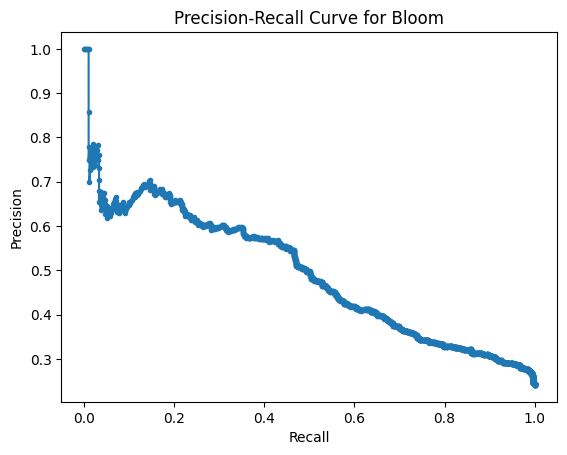

PR AUC: 0.49291638063426013


In [159]:
# Plot PR curve

# Bloom occurs if y >= 0.5
y_binary = (y_lr_bloom >= 0.5).astype(int)

from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Predicted probabilities (or just predictions from linear regression)
y_scores = y_pred_bloom  # your continuous predictions

precision, recall, thresholds = precision_recall_curve(y_binary, y_scores)

# Plot
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Bloom")
plt.show()

# Optional: area under the PR curve
pr_auc = auc(recall, precision)
print("PR AUC:", pr_auc)